# IGS-GA constraint relaxation: grillage design

Find a stakeholder-preferred compromise between cost, construction time, budget relaxation, and time relaxation while meeting a fixed safety threshold. This is an illustrative model, not a validated structural design calculation or a guarantee of a global minimum.

The notebook owns all example-specific inputs and equations. `IGSGA` and its affine aggregator come from `src/optimization`; preference construction and plotting come from `src/utils`. No example-local Python scripts are needed.

The model contract is `(design, steel; fixed scenario) -> cost, construction_time, safety`. The GA searches four variables: design index, steel amount, additional budget, and additional time. Safety is never relaxed.

Use a Python environment with this project's dependencies installed (`pip install -e .`) and a Jupyter kernel. Run the cells in order from within the repository.

In [1]:
import sys
from math import exp
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from IPython.display import display
from pymoo.core.problem import ElementwiseProblem
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.termination import get_termination

PROJECT_ROOT = next(
    (directory for directory in (Path.cwd(), *Path.cwd().parents)
     if (directory / "src" / "optimization" / "igs_ga.py").is_file()),
    None,
 )
if PROJECT_ROOT is None:
    raise RuntimeError("Run this notebook from within the IGS-GA-II repository.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from optimization.igs_ga import IGSGA
from utils.imap_helpers import build_imap_config
from utils.imap_plotting import plot_preference_functions

## Configuration

All study inputs are defined here: design alternatives, fixed limits, maximum permitted relaxations, solver settings, and stakeholder preferences. Cost is in kEUR, time in days, steel in kg/m2, and safety is dimensionless.

The steel ratio in the illustrative model is normalized over `MIN_STEEL` to `MAX_STEEL`; changing these limits also changes the model's response at a given steel amount. All four objectives are minimized. Objective weights and stakeholder influence weights must each sum to one.

In [2]:
DESIGNS = pd.DataFrame(
    [
        ("A", "Lean frame", 0.95, 1.15, 0.78, 0.55, 0.06),
        ("B", "Balanced frame", 1.05, 0.95, 0.75, 0.48, 0.04),
        ("C", "Rapid frame", 1.10, 0.85, 0.72, 0.62, 0.03),
        ("D", "Economy frame", 1.25, 0.75, 0.70, 0.58, 0.08),
        ("E", "Robust frame", 1.00, 1.10, 0.76, 0.52, 0.10),
    ],
    columns=["design_id", "name", "cost_multiplier", "time_multiplier",
             "base_safety", "safety_multiplier", "interaction"],
).set_index("design_id")

MIN_STEEL = 20.0
MAX_STEEL = 80.0
SAFETY_THRESHOLD = 1.20
BUDGET = 110.0
TIME_LIMIT = 10.0
BASE_COST = 100.0
BASE_TIME = 10.0
MAX_BUDGET_RELAXATION = 50.0
MAX_TIME_RELAXATION = 3.0

POP_SIZE = 100
N_GEN = 20
SEED = 42
TOURNAMENT_SELECTION = True
ARCHIVE = True
ARCHIVE_MAX_SIZE = 50
CV_WEIGHT = 0.5
CV_SCALE = 10.0
FEASIBILITY_TOL = 1e-9
GRID_POINTS = 61

OBJECTIVES = ["cost", "construction_time", "budget_relaxation", "time_relaxation"]
OBJECTIVE_LABELS = ["Cost (kEUR)", "Time (days)", "Budget relaxation (kEUR)", "Time relaxation (days)"]
STAKEHOLDERS = [
    {"obj_weights": [0.2, 0.2, 0.3, 0.3], "weight": 1.0, "pref_shape": "linear"},
]

if not 0 <= MIN_STEEL < MAX_STEEL:
    raise ValueError("Steel limits must satisfy 0 <= MIN_STEEL < MAX_STEEL.")
if min(SAFETY_THRESHOLD, BUDGET, TIME_LIMIT, BASE_COST, BASE_TIME,
       MAX_BUDGET_RELAXATION, MAX_TIME_RELAXATION) <= 0:
    raise ValueError("Scenario values and maximum relaxations must be positive.")
if POP_SIZE < 2 or N_GEN < 1 or GRID_POINTS < 2:
    raise ValueError("Use POP_SIZE >= 2, N_GEN >= 1, and GRID_POINTS >= 2.")
if not 0 < CV_WEIGHT < 1 or CV_SCALE <= 0:
    raise ValueError("Use 0 < CV_WEIGHT < 1 and CV_SCALE > 0.")
if DESIGNS.empty or not DESIGNS.index.is_unique:
    raise ValueError("Provide at least one design with unique design IDs.")
if not STAKEHOLDERS or not np.isclose(sum(cfg["weight"] for cfg in STAKEHOLDERS), 1.0):
    raise ValueError("Stakeholder weights must sum to one.")
for cfg in STAKEHOLDERS:
    weights = np.asarray(cfg["obj_weights"], dtype=float)
    if (weights.shape != (len(OBJECTIVES),) or not np.isfinite(weights).all()
            or np.any(weights < 0) or not np.isclose(weights.sum(), 1.0)
            or not np.isfinite(cfg["weight"]) or cfg["weight"] < 0):
        raise ValueError("Use nonnegative, finite weights with one weight per objective, summing to one.")

display(DESIGNS)

,name,cost_multiplier,time_multiplier,base_safety,safety_multiplier,interaction
design_id,,,,,,
A,Lean frame,0.95,1.15,0.78,0.55,0.06
B,Balanced frame,1.05,0.95,0.75,0.48,0.04
C,Rapid frame,1.10,0.85,0.72,0.62,0.03
D,Economy frame,1.25,0.75,0.70,0.58,0.08
E,Robust frame,1.00,1.10,0.76,0.52,0.10


## 1. Grillage Model

`evaluate_design` contains the example-specific cost, time, and safety equations, unchanged from the original study. The sampled design space is used for visualization and preference bounds, not as a replacement for the GA search.

The cell checks the model contract for the rapid frame at 70% of the steel range (62 kg/m2 by default), which is safe and fits within the default maximum relaxations. Changing the scenario can make this point infeasible; the check reports that without claiming the whole problem is infeasible.

In [3]:
def evaluate_design(design_id, steel):
    if design_id not in DESIGNS.index:
        raise ValueError(f"Unknown design: {design_id}")
    if not MIN_STEEL <= steel <= MAX_STEEL:
        raise ValueError("Steel must be within the configured limits.")
    design = DESIGNS.loc[design_id]
    steel_ratio = (steel - MIN_STEEL) / (MAX_STEEL - MIN_STEEL)
    cost = BASE_COST * float(design["cost_multiplier"]) * (1 + 0.55 * steel_ratio**1.8)
    construction_time = BASE_TIME * float(design["time_multiplier"]) * (1 + 0.70 * steel_ratio**1.55)
    safety = (
        float(design["base_safety"])
        + float(design["safety_multiplier"]) * (1 - exp(-2.1 * steel_ratio))
        + float(design["interaction"]) * steel_ratio**2
    )
    return {"cost": cost, "construction_time": construction_time, "safety": safety}


sample_points = pd.DataFrame([
    {"design_id": design_id, "steel": float(steel), **evaluate_design(design_id, float(steel))}
    for design_id in DESIGNS.index
    for steel in np.linspace(MIN_STEEL, MAX_STEEL, GRID_POINTS)
])
sample_points["is_safe"] = sample_points["safety"] >= SAFETY_THRESHOLD
sample_points["is_acceptable"] = (
    sample_points["is_safe"]
    & (sample_points["cost"] <= BUDGET)
    & (sample_points["construction_time"] <= TIME_LIMIT)
)

smoke_design = "C" if "C" in DESIGNS.index else DESIGNS.index[0]
smoke_steel = MIN_STEEL + 0.7 * (MAX_STEEL - MIN_STEEL)
smoke_metrics = evaluate_design(smoke_design, smoke_steel)
assert set(smoke_metrics) == {"cost", "construction_time", "safety"}
assert np.isfinite(list(smoke_metrics.values())).all()
smoke_feasible = (
    smoke_metrics["safety"] >= SAFETY_THRESHOLD
    and smoke_metrics["cost"] <= BUDGET + MAX_BUDGET_RELAXATION
    and smoke_metrics["construction_time"] <= TIME_LIMIT + MAX_TIME_RELAXATION
)
print(f"Model smoke test: design {smoke_design}, steel {smoke_steel:g} kg/m2")
print(smoke_metrics)
print(f"Feasible within maximum relaxations: {smoke_feasible}")
print(f"Sampled points within original limits: {sample_points['is_acceptable'].sum()}")

Model smoke test: design C, steel 62 kg/m2
{'cost': 141.83697868562945, 'construction_time': 11.923094807816884, 'safety': 1.212146199184231}
Feasible within maximum relaxations: True
Sampled points within original limits: 0


## 2. Problem Setup

| Decision variable | Encoding | Bounds |
|---|---|---|
| Design | Real-valued key, floored to a catalogue index | `[0, number of designs)` |
| Steel | Continuous, kg/m2 | `MIN_STEEL` to `MAX_STEEL` |
| Budget relaxation | Continuous, kEUR | `0` to `MAX_BUDGET_RELAXATION` |
| Time relaxation | Continuous, days | `0` to `MAX_TIME_RELAXATION` |

The real-key design encoding preserves the original study's search behavior. `F` follows `OBJECTIVES` order. Pymoo inequalities use `G <= 0`: cost must fit the relaxed budget, construction time must fit the relaxed time limit, and safety must meet the unchanged threshold.

The original budget and time limits are not additional hard constraints: their relaxation amounts are decision variables and objectives. No custom selection or aggregation is implemented here.

In [4]:
def decode_design(design_key):
    index = min(int(np.floor(design_key)), len(DESIGNS) - 1)
    return DESIGNS.index[index]


class GrillageRelaxationProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=4,
            n_obj=len(OBJECTIVES),
            n_ieq_constr=3,
            xl=np.array([0.0, MIN_STEEL, 0.0, 0.0]),
            xu=np.array([len(DESIGNS) - 1e-9, MAX_STEEL,
                         MAX_BUDGET_RELAXATION, MAX_TIME_RELAXATION]),
        )

    def _evaluate(self, decision, out, *args, **kwargs):
        metrics = evaluate_design(decode_design(decision[0]), float(decision[1]))
        budget_relaxation, time_relaxation = float(decision[2]), float(decision[3])
        values = {**metrics, "budget_relaxation": budget_relaxation, "time_relaxation": time_relaxation}
        out["F"] = [values[name] for name in OBJECTIVES]
        out["G"] = [
            metrics["cost"] - (BUDGET + budget_relaxation),
            metrics["construction_time"] - (TIME_LIMIT + time_relaxation),
            SAFETY_THRESHOLD - metrics["safety"],
        ]


problem = GrillageRelaxationProblem()
smoke_decision = np.array([
    DESIGNS.index.get_loc(smoke_design), smoke_steel,
    MAX_BUDGET_RELAXATION, MAX_TIME_RELAXATION,
], dtype=float)
smoke_out = problem.evaluate(smoke_decision, return_as_dictionary=True)
print(f"Variables: {problem.n_var}; objectives: {problem.n_obj}; constraints: {problem.n_constr}")
print("Smoke-test objectives:", dict(zip(OBJECTIVES, smoke_out["F"])))
print("Smoke-test inequalities:", smoke_out["G"])

Variables: 4; objectives: 4; constraints: 3
Smoke-test objectives: {'cost': np.float64(141.83697868562945), 'construction_time': np.float64(11.923094807816884), 'budget_relaxation': np.float64(50.0), 'time_relaxation': np.float64(3.0)}
Smoke-test inequalities: [-1.81630213e+01 -1.07690519e+00 -1.21461992e-02]


## 3. Preference Functions

`build_imap_config` supplies the preference functions, objective weights, and stakeholder weights expected by `IGSGA`. Bounds for cost and time span the full sampled design space, including unsafe designs, as in the original study. The grid includes both steel endpoints, so it captures the extrema of the current monotone cost/time equations.

The CV preference remains `100 / (1 + CV_SCALE * cv)`, with `cv = sum(max(0, G))`, to preserve the original search behavior. This is a study-specific policy; the shared `make_pref_cv` has a different, step-shaped policy. `CV_WEIGHT` controls its aggregation weight, while the solver's constraint-domination logic prioritizes feasibility. A CV weight of 0.5 alone is not a feasibility guarantee.

The shared `plot_preference_functions` draws all stakeholder curves.

,Lower bound,Upper bound
cost,95.0,193.75
construction_time,7.5,19.55
budget_relaxation,0.0,50.00
time_relaxation,0.0,3.00


,1
Objective,
cost,0.2
construction_time,0.2
budget_relaxation,0.3
time_relaxation,0.3


Stakeholder influence weights: [1.0]


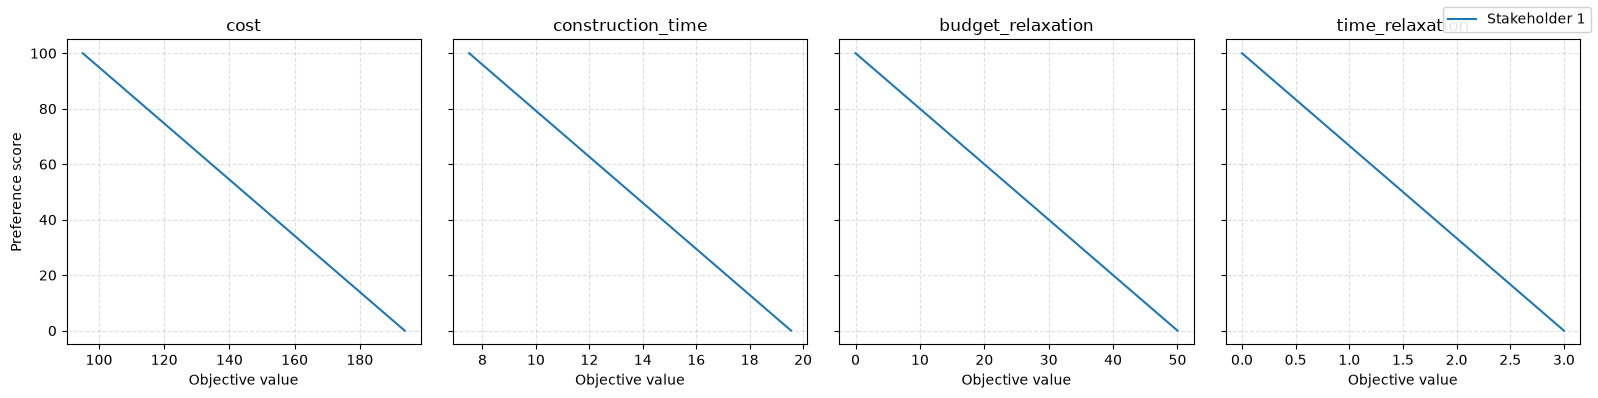

In [5]:
obj_bounds = [
    (float(sample_points["cost"].min()), float(sample_points["cost"].max())),
    (float(sample_points["construction_time"].min()), float(sample_points["construction_time"].max())),
    (0.0, MAX_BUDGET_RELAXATION),
    (0.0, MAX_TIME_RELAXATION),
]
preference_functions, objective_weights, stakeholder_weights = build_imap_config(
    n_obj=len(OBJECTIVES),
    obj_bounds=obj_bounds,
    obj_names=OBJECTIVES,
    stakeholder_configs=STAKEHOLDERS,
)


def cv_pref_fn(cv):
    return float(100.0 / (1.0 + CV_SCALE * cv))


display(pd.DataFrame(obj_bounds, index=OBJECTIVES, columns=["Lower bound", "Upper bound"]))
display(pd.DataFrame(objective_weights).rename_axis("Objective"))
print("Stakeholder influence weights:", stakeholder_weights)
fig = plot_preference_functions(preference_functions, obj_bounds, OBJECTIVES)
plt.show()

## 4. Run IGS-GA

Construct `IGSGA` directly and pass it to `pymoo_minimize`, as in the DAS-CMOP example. The library owns aggregation, survival, archive management, and best-solution tracking.

The reported IMAP score is relative to the solver's final second-pass comparison pool, including its archive reference points when enabled. It is not an absolute utility and should not be compared across independent runs.

The result is reevaluated against the model and constraints before display. If no feasible incumbent was found, the cell stops with its violation rather than claiming a safe design. This does not prove that no feasible solution exists.

In [6]:
algorithm = IGSGA(
    preference_functions=preference_functions,
    objective_weights=objective_weights,
    stakeholder_weights=stakeholder_weights,
    all_objectives=OBJECTIVES,
    pop_size=POP_SIZE,
    tournament_selection=TOURNAMENT_SELECTION,
    archive=ARCHIVE,
    archive_max_size=ARCHIVE_MAX_SIZE,
    cv_pref_fn=cv_pref_fn,
    cv_weight=CV_WEIGHT,
    seed=SEED,
    verbose=False,
)
res = pymoo_minimize(
    problem, algorithm, get_termination("n_gen", N_GEN),
    seed=SEED, verbose=False, copy_algorithm=False,
)

best = algorithm.current_best
if best is None:
    raise RuntimeError("IGS-GA did not return an incumbent.")
best_decision = np.asarray(best.get("X"), dtype=float)
best_out = problem.evaluate(best_decision, return_as_dictionary=True)
best_objectives = np.asarray(best_out["F"], dtype=float)
best_constraints = np.asarray(best_out["G"], dtype=float)
best_cv = float(np.maximum(0.0, best_constraints).sum())
if not np.isfinite(best_constraints).all() or best_cv > FEASIBILITY_TOL:
    raise RuntimeError(
        f"No feasible incumbent found (CV={best_cv:.6g}). "
        "Review the allowed relaxations or increase the search budget before accepting a design."
    )

best_design = decode_design(best_decision[0])
best_steel = float(best_decision[1])
best_metrics = evaluate_design(best_design, best_steel)
relaxed_budget = BUDGET + best_decision[2]
relaxed_time_limit = TIME_LIMIT + best_decision[3]
required_relaxations = np.array([
    max(0.0, best_metrics["cost"] - BUDGET),
    max(0.0, best_metrics["construction_time"] - TIME_LIMIT),
])

population_decisions = np.asarray(res.pop.get("X"), dtype=float)
population_out = problem.evaluate(population_decisions, return_as_dictionary=True)
population_cv = np.maximum(0.0, population_out["G"]).sum(axis=1)
feasible_mask = population_cv <= FEASIBILITY_TOL
feasible_objectives = population_out["F"][feasible_mask]

print(f"Preferred design: {best_design} ({DESIGNS.loc[best_design, 'name']})")
print(f"Found at solver generation index {algorithm.current_best_gen} (initial population = 0)")
print(f"Final population: {feasible_mask.sum()}/{len(population_decisions)} feasible")
print(f"Steel: {best_steel:.2f} kg/m2; cost: {best_metrics['cost']:.2f} kEUR; "
      f"time: {best_metrics['construction_time']:.2f} days; safety: {best_metrics['safety']:.4f}")
print(f"Budget: {BUDGET:.2f} -> {relaxed_budget:.2f} kEUR "
      f"(+{best_decision[2]:.2f}; tight requirement +{required_relaxations[0]:.2f})")
print(f"Time: {TIME_LIMIT:.2f} -> {relaxed_time_limit:.2f} days "
      f"(+{best_decision[3]:.2f}; tight requirement +{required_relaxations[1]:.2f})")
print(f"Constraint violation: {best_cv:.6g}")
print(f"Relative IMAP score in final selection context: {float(best.get('imap_score')):.4f}")

preference_values = pd.DataFrame({
    f"Stakeholder {stakeholder}": [
        preference_functions[stakeholder][name](float(value))
        for name, value in zip(OBJECTIVES, best_objectives)
    ]
    for stakeholder in preference_functions
}, index=OBJECTIVES)
preference_values.insert(0, "Raw value", best_objectives)
display(preference_values)

Preferred design: C (Rapid frame)
Found at solver generation index 19 (initial population = 0)
Final population: 99/100 feasible
Steel: 60.06 kg/m2; cost: 139.24 kEUR; time: 11.68 days; safety: 1.2008
Budget: 110.00 -> 139.91 kEUR (+29.91; tight requirement +29.24)
Time: 10.00 -> 11.70 days (+1.70; tight requirement +1.68)
Constraint violation: 0
Relative IMAP score in final selection context: 92.4555


,Raw value,Stakeholder 1
cost,139.241933,55.198042
construction_time,11.681425,65.299374
budget_relaxation,29.909129,40.181742
time_relaxation,1.697709,43.409684


## 5. Results

### 5a. Original and Relaxed Acceptable Regions

The grid shows safe and unsafe designs in cost/time space. Rectangles mark the original and GA-selected budget/time limits. A point inside a rectangle is only acceptable if it also meets the safety threshold.

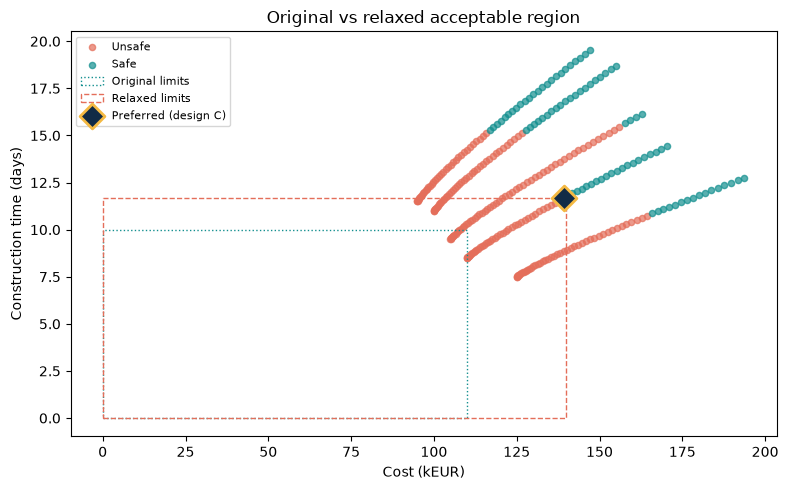

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for is_safe, label, color in [(False, "Unsafe", "#e46e5a"), (True, "Safe", "#138f8f")]:
    subset = sample_points[sample_points["is_safe"] == is_safe]
    ax.scatter(subset["cost"], subset["construction_time"],
               color=color, alpha=0.7, s=20, label=label)
ax.add_patch(Rectangle((0, 0), BUDGET, TIME_LIMIT, fill=False,
                       edgecolor="#138f8f", linestyle=":", label="Original limits"))
ax.add_patch(Rectangle((0, 0), relaxed_budget, relaxed_time_limit, fill=False,
                       edgecolor="#e46e5a", linestyle="--", label="Relaxed limits"))
ax.scatter(best_metrics["cost"], best_metrics["construction_time"],
           color="#112b46", edgecolor="#f4b942", linewidth=2, s=160, marker="D",
           zorder=5, label=f"Preferred (design {best_design})")
ax.set(xlabel="Cost (kEUR)", ylabel="Construction time (days)",
       title="Original vs relaxed acceptable region")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

### 5b. Relaxation as a Share of the Allowed Maximum

The GA chooses relaxation amounts as explicit decision variables. The tight requirement is the minimum extra budget/time needed **for the selected design and steel amount**, not a separately optimized design. The difference between the two bars is unused allowance.

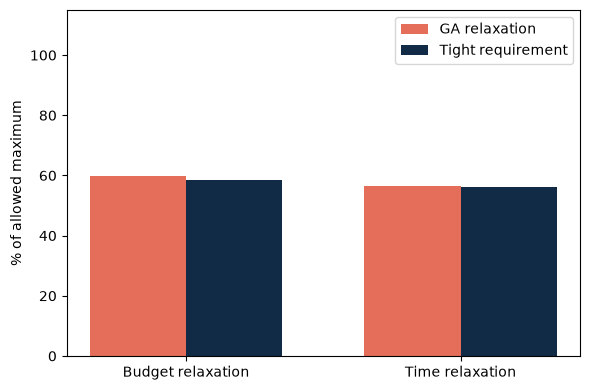

In [8]:
maximum_relaxations = np.array([MAX_BUDGET_RELAXATION, MAX_TIME_RELAXATION])
ga_percentages = 100.0 * best_decision[2:] / maximum_relaxations
tight_percentages = 100.0 * required_relaxations / maximum_relaxations
positions = np.arange(2)
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(positions - width / 2, ga_percentages, width, color="#e46e5a", label="GA relaxation")
ax.bar(positions + width / 2, tight_percentages, width, color="#112b46", label="Tight requirement")
ax.set_xticks(positions, ["Budget relaxation", "Time relaxation"])
ax.set(ylabel="% of allowed maximum", ylim=(0, 115))
ax.legend()
fig.tight_layout()
plt.show()

### 5c. Preferred Design on the Preference Curves

Reuse `plot_preference_functions` and annotate its returned axes with feasible final-population values and the selected design, for every configured stakeholder. Curve construction remains in the shared utility. Individual preference values are in [0, 100]; they are not the context-dependent aggregate score.

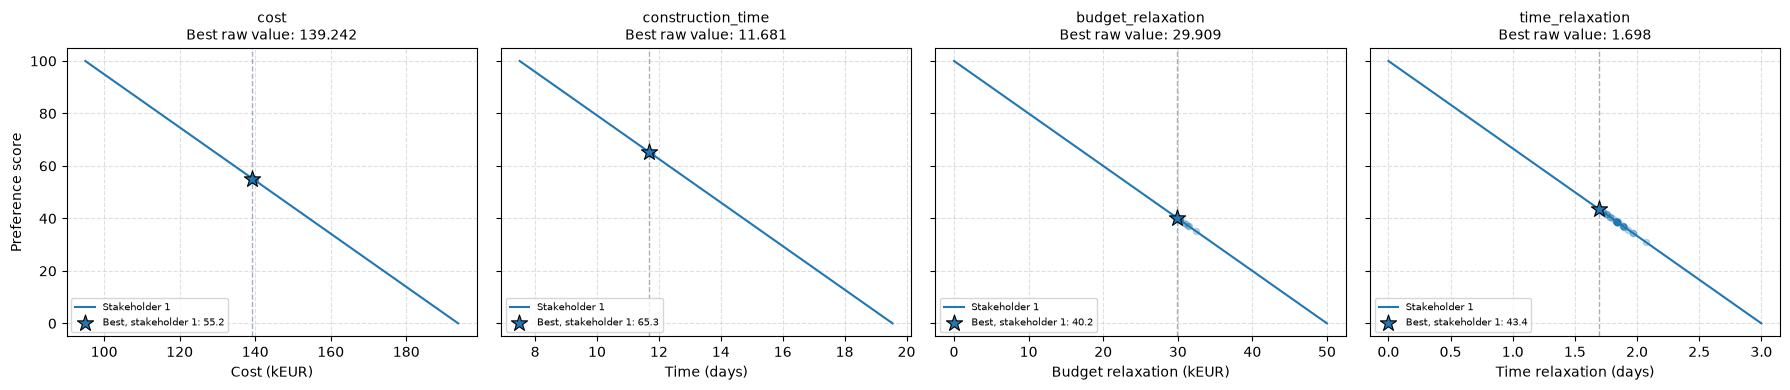

In [9]:
fig = plot_preference_functions(
    preference_functions, obj_bounds, OBJECTIVES, fig_size_per_obj=(4.5, 4.0),
)
for column, (ax, name, label) in enumerate(zip(fig.axes, OBJECTIVES, OBJECTIVE_LABELS)):
    best_value = float(best_objectives[column])
    population_values = np.unique(feasible_objectives[:, column])
    for line, stakeholder in zip(ax.lines, preference_functions):
        preference = preference_functions[stakeholder][name]
        color = line.get_color()
        ax.scatter(population_values, [preference(float(value)) for value in population_values],
                   color=color, alpha=0.25, s=20)
        ax.scatter(best_value, preference(best_value), color=color, edgecolor="black",
                   linewidth=0.8, s=150, marker="*", zorder=5,
                   label=f"Best, stakeholder {stakeholder}: {preference(best_value):.1f}")
    ax.axvline(best_value, color="#6b7a8d", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xlabel(label)
    ax.set_title(f"{name}\nBest raw value: {best_value:.3f}", fontsize=10)
    ax.legend(fontsize=7, loc="lower left")
for legend in list(fig.legends):
    legend.remove()
fig.tight_layout()
plt.show()